# Spike sorting `CSC29.ncs` with SpikeInterface

Reproducing the [Combinato **Real Data** tutorial](https://github.com/jniediek/combinato/wiki/Tutorial-Real-Data) — a single-channel human hippocampal Neuralynx recording — with the SpikeInterface pipeline instead of the `css-*` command-line tools.

| Combinato step | What it does | SpikeInterface equivalent |
|---|---|---|
| `css-extract` | band-pass filter + threshold spike detection | `bandpass_filter` + `detect_peaks` |
| `css-mask-artifacts` | drop artifact-dominated epochs | amplitude / noise-based masking |
| `css-simple-clustering` | group spikes into units | `run_sorter` |
| `css-plot-sorted` | per-unit overview figures | `SortingAnalyzer` + plotting widgets |
| `css-gui` | manual merge/reject | `spikeinterface-gui` / sortingview |

In [1]:
import spikeinterface.full as si

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print(f"spikeinterface version: {si.__version__}")

spikeinterface version: 0.104.5


## 1. Load the raw Neuralynx recording  ·  `css-extract` (read step)

The Combinato tutorial runs on `CSC29.ncs`, one micro-wire channel from the left hippocampus. `read_neuralynx` takes the **folder** containing the `.ncs` file(s); since `data_real/` holds only `CSC29.ncs`, this loads it as a single-channel recording.

We also attach a one-contact dummy probe — a single-channel recording has no geometry, but the sorter in step 5 needs channel locations to exist.

In [4]:
from probeinterface import Probe

base = Path("data_real")  # folder that contains CSC29.ncs

raw_rec = si.read_neuralynx(folder_path=base)

# single-channel dummy probe so downstream sorters have channel geometry
probe = Probe(ndim=2, si_units="um")
probe.set_contacts(positions=[[0.0, 0.0]], shapes="circle", shape_params={"radius": 6})
probe.set_device_channel_indices([0])
raw_rec = raw_rec.set_probe(probe)

fs = raw_rec.get_sampling_frequency()
print(raw_rec)
print(f"\nsampling rate : {fs:,.0f} Hz")
print(f"duration      : {raw_rec.get_duration():.1f} s")
print(f"channel ids   : {raw_rec.get_channel_ids()}")

NeuralynxRecordingExtractor: 1 channels - 32.0kHz - 1 segments - 61,757,440 samples 
                             1,929.92s (32.17 minutes) - int16 dtype - 117.79 MiB

sampling rate : 32,000 Hz
duration      : 1929.9 s
channel ids   : ['60']


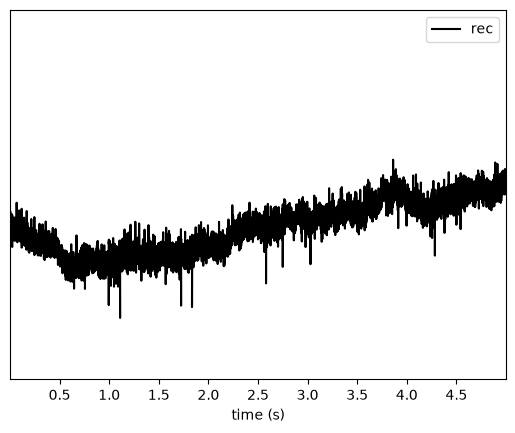

In [5]:
# quick look at 5 s of the raw trace
w_ts = si.plot_traces(raw_rec, time_range=(0, 5))

## 2. Band-pass filter — 300–3000 Hz  ·  `css-extract` (filter step)

`css-extract` band-passes the raw trace before detecting spikes. 300–3000 Hz is the standard band for human MTL micro-wire data. Filtering in SpikeInterface is **lazy** — nothing is computed until you pull traces or run detection.

In [6]:
rec_f = si.bandpass_filter(raw_rec, freq_min=300.0, freq_max=3000.0)
rec_f

BandpassFilterRecording: 1 channels - 32.0kHz - 1 segments - 61,757,440 samples 
                         1,929.92s (32.17 minutes) - int16 dtype - 117.79 MiB

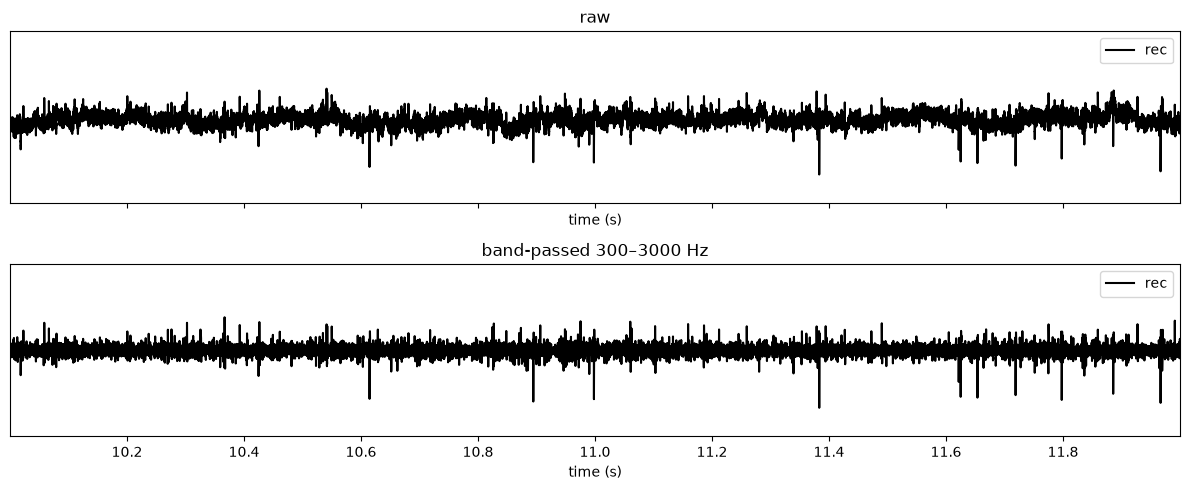

In [7]:
# raw vs. band-passed, same 2 s window
fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
si.plot_traces(raw_rec, time_range=(10, 12), ax=axs[0])
axs[0].set_title("raw")
si.plot_traces(rec_f, time_range=(10, 12), ax=axs[1])
axs[1].set_title("band-passed 300–3000 Hz")
fig.tight_layout()

## 3. Detect spikes — 5 × MAD threshold  ·  `css-extract` (detect step)

`css-extract` extracts events crossing a threshold of **5 × σ**, where σ is estimated robustly as `median(|x|) / 0.6745` (Quiroga 2004). `detect_peaks` uses the same MAD-based noise estimate, so `detect_threshold=5` is the direct equivalent. Combinato detects negative and positive events separately; micro-wire spikes are predominantly **negative**, so we start with `peak_sign="neg"`.

In [8]:
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

job_kwargs = dict(n_jobs=-1, chunk_duration="1s", progress_bar=True)

peaks = detect_peaks(
    rec_f,
    method="by_channel",
    peak_sign="neg",
    detect_threshold=5,        # 5 x MAD, same as Combinato's 5 x sigma
    exclude_sweep_ms=0.5,      # refractory window for the detector
    **job_kwargs,
)

print(f"{len(peaks):,} spikes detected "
      f"({len(peaks) / rec_f.get_duration():.1f} Hz mean rate)")

/Users/alexanderflores/spikesorting/.venv/lib/python3.13/site-packages/spikeinterface/sortingcomponents/peak_detection/main.py:60: UserWarning: The signature of detect_peaks() has changed, now method_kwargs and job_kwargs are dinstinct params.This warning will raise an error in version 0.105.0
  warnings.warn(


noise_level (workers: 16 processes spawn):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (by_channel) (workers: 16 processes spawn):   0%|          | 0/1930 [00:00<?, ?it/s]

29,688 spikes detected (15.4 Hz mean rate)


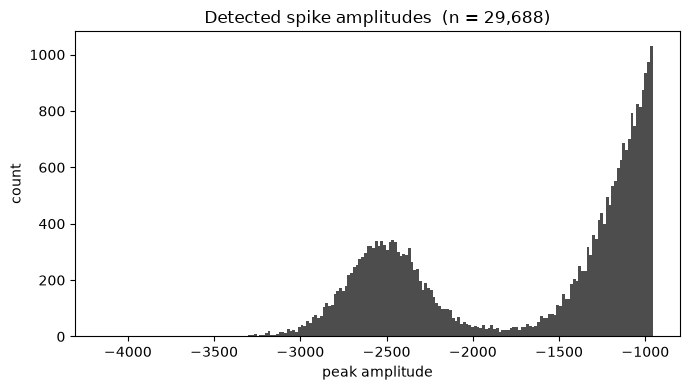

In [9]:
# amplitude distribution of detected events (in MAD-normalised units)
amps = peaks["amplitude"]
plt.figure(figsize=(7, 4))
plt.hist(amps, bins=200, color="0.3")
plt.xlabel("peak amplitude")
plt.ylabel("count")
plt.title(f"Detected spike amplitudes  (n = {len(amps):,})")
plt.tight_layout()

## 4. Artifact masking  ·  `css-mask-artifacts`

`css-mask-artifacts` removes stretches dominated by artifacts (saturation, large synchronous deflections) before clustering.

> ⚠️ **Note:** SpikeInterface's Combinato wrapper does **not** run `css-mask-artifacts` — it only calls `css-extract` + `css-simple-clustering` (you can confirm this in `spikeinterface/sorters/external/combinato.py`, and in the run log: `No artifacts defined`). So the sort in step 5 does **no** artifact masking.

On a single channel the simplest analogue is to flag events whose amplitude is far outside the spike distribution — extreme deflections are almost always artifacts, not neurons. Below we *report* how many detected events sit above a generous amplitude cut. To actually remove them you could either run `python css-mask-artifacts ...` by hand on the sorter's `recording/data_recording.h5`, or insert `si.remove_artifacts(...)` as a preprocessing step before sorting.

In [10]:
hi = np.percentile(np.abs(amps), 99.9)
n_artifact = int((np.abs(amps) > hi).sum())
print(f"{n_artifact} events ({n_artifact / len(amps) * 100:.2f}%) exceed the "
      f"99.9th-percentile amplitude (|amp| > {hi:.1f}) — likely artifacts")

30 events (0.10%) exceed the 99.9th-percentile amplitude (|amp| > 3314.2) — likely artifacts


## 5. Cluster the spikes into units  ·  `css-simple-clustering`

`css-simple-clustering` groups the extracted spikes into putative neurons. SpikeInterface ships an **external-sorter wrapper for Combinato itself**, so `run_sorter("combinato", ...)` shells out to the real Combinato scripts. Its default params already match the tutorial (`detect_sign=-1`, `detect_threshold=5`, etc.).

**What the wrapper actually runs** (see `_run_from_folder` in `spikeinterface/sorters/external/combinato.py`):

```
python css-extract --h5 --files recording.h5                 # filter + detect + extract
python css-simple-clustering --neg --datafile .../data_recording.h5   # cluster
```

So it runs **two** of the tutorial's steps — `css-extract` and `css-simple-clustering` — but **not** `css-mask-artifacts` (see step 4).

`css-extract` does its own filtering and detection (Combinato's `basics/filters.py`): elliptic bandpass **300–1000 Hz for detection**, **300–3000 Hz for the stored waveform**, plus a ~2 kHz notch (`denoise=True`). It therefore takes the **raw** recording — `rec_f` from step 2 was only for visualization, and note step 2's 300–3000 Hz is Combinato's *extraction* band, not its narrower *detection* band.

Combinato isn't a pip package; the wrapper just needs the cloned repo's path via `set_combinato_path` (or the `COMBINATO_PATH` env var), with `setup_options.py` already run once.

> Swap back to a built-in sorter any time: `run_sorter("spykingcircus2", raw_rec, ...)` or `"tridesclous2"`.

In [11]:
import os
from spikeinterface.sorters import CombinatoSorter

# Point the wrapper at your local Combinato clone.
#   git clone https://github.com/jniediek/combinato
#   cd combinato && python3 setup_options.py     # run once
# Then set COMBINATO_PATH in your shell, or edit the fallback path below.
combinato_path = os.environ.get("COMBINATO_PATH", str(Path.home() / "combinato"))
CombinatoSorter.set_combinato_path(combinato_path)
print("Using Combinato at:", combinato_path)

sorting = si.run_sorter(
    "combinato",
    raw_rec,
    folder="results/combinato",
    remove_existing_folder=True,
    detect_sign=-1 ,         # negative spikes, as in the tutorial
    detect_threshold=5,     # 5 x sigma
    verbose=True,
)
print(sorting)
print("unit ids:", sorting.unit_ids)

Setting COMBINATO_PATH environment variable for subprocess calls to: /Users/alexanderflores/combinato
Using Combinato at: /Users/alexanderflores/combinato


Running combinato in /Users/alexanderflores/spikesorting/results/combinato/sorter_output...
RUNNING SHELL SCRIPT: /Users/alexanderflores/spikesorting/results/combinato/sorter_output/run_combinato.sh


2026-07-01 15:10:20 [DEBUG  ] combinato: Logging configured: level=DEBUG, dir=/Users/alexanderflores/spikesorting/results/combinato/sorter_output/logs/20260701

2026-07-01 15:10:20 [INFO   ] combinato: Updated 17 options from local_options



2026-07-01 15:10:20 [INFO   ] combinato.extract.extract_spikes: Updated 17 options by local_options

2026-07-01 15:10:20 [DEBUG  ] combinato: Logging configured: level=DEBUG, dir=/Users/alexanderflores/spikesorting/results/combinato/sorter_output/logs/20260701

2026-07-01 15:10:20 [INFO   ] combinato: Updated 17 options from local_options

2026-07-01 15:10:20 [DEBUG  ] combinato: Logging configured: level=DEBUG, dir=/Users/alexanderflores/spikesorting/results/combinato/sorter_output/logs/20260701

2026-07-01 15:10:20 [DEBUG  ] combinato: Logging configured: level=DEBUG, dir=/Users/alexanderflores/spikesorting/results/combinato/sorter_output/logs/20260701

2026-07-01 15:10:20 [INFO   ] combinato: Updated 17 options from local_options

2026-07-01 15:10:20 [INFO   ] combinato: Updated 17 options from local_options

2026-07-01 15:10:20 [DEBUG  ] combinato: Logging configured: level=DEBUG, dir=/Users/alexanderflores/spikesorting/results/combinato/sorter_output/logs/20260701

2026-07-01 15:1

2026-07-01 15:10:21 [INFO   ] combinato.extract.extract_spikes: Updated 17 options by local_options

2026-07-01 15:10:21 [INFO   ] combinato.extract.extract_spikes: Updated 17 options by local_options

2026-07-01 15:10:21 [INFO   ] combinato.extract.extract_spikes: Updated 17 options by local_options

2026-07-01 15:10:21 [INFO   ] combinato.extract.extract_spikes: Updated 17 options by local_options

2026-07-01 15:10:21 [INFO   ] combinato.extract.extract_spikes: Updated 17 options by local_options

2026-07-01 15:10:21 [INFO   ] combinato.extract.extract_spikes: Updated 17 options by local_options

2026-07-01 15:10:21 [INFO   ] combinato.extract.extract_spikes: Updated 17 options by local_options

2026-07-01 15:10:21 [INFO   ] combinato.extract.mp_extract: Read exited

/Users/alexanderflores/spikesorting/.venv/lib/python3.13/site-packages/tables/file.py:130: UnclosedFileWarning: Closing remaining open file: recording.h5

  warnings.warn(UnclosedFileWarning(msg))



...

2026-07-01 15:11:29 [DEBUG  ] combinato.cluster.concatenate: Plotting 17/24, recording/sort_neg_simple, 806 spikes

2026-07-01 15:11:29 [DEBUG  ] combinato.cluster.concatenate: Plotting 18/24, recording/sort_neg_simple, 1180 spikes



2026-07-01 15:11:29 [DEBUG  ] combinato.cluster.concatenate: Plotting 19/24, recording/sort_neg_simple, 1113 spikes

2026-07-01 15:11:29 [DEBUG  ] combinato.cluster.concatenate: Plotting 20/24, recording/sort_neg_simple, 1077 spikes



2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.concatenate: Plotting 21/24, recording/sort_neg_simple, 818 spikes

2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.concatenate: Plotting 22/24, recording/sort_neg_simple, 1188 spikes



2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.concatenate: Plotting 23/24, recording/sort_neg_simple, 1603 spikes

2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.concatenate: Plotting 24/24, recording/sort_neg_simple, 1677 spikes



2026-07-01 15:11:30 [INFO   ] combinato.cluster.concatenate: Plotted classes in recording/sort_neg_simple

2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.concatenate: recording/sort_neg_simple/sort_cat.h5 [[ 0  0]

 [ 1  0]

 [ 2  0]

 [ 4  0]

 [ 5  0]

 [ 6  0]

 [ 7  0]

 [ 8  0]

 [ 9  0]

 [10  0]

 [11  0]

 [12  0]

 [13  0]

 [14  0]

 [16  0]

 [17  0]

 [18  0]

 [19  0]

 [20  0]

 [21  0]

 [22  0]

 [23  0]

 [24  0]

 [25  0]]

2026-07-01 15:11:30 [DEBUG  ] combinato.manager.manager: No artifacts defined

2026-07-01 15:11:30 [DEBUG  ] combinato.manager.manager: No artifacts defined

2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.create_groups: Read 28002 spikes

2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.create_groups: Classes: [ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 20 21 22 23 24 25]

2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.create_groups: Merging 9 and 14, dist: 0.3176

2026-07-01 15:11:30 [DEBUG  ] combinato.cluster.create_groups: Merging 

## 6. Inspect the sorted units  ·  `css-plot-sorted`

`css-plot-sorted` produces a per-unit overview figure (mean waveform, spike shapes, firing stats). In SpikeInterface we build a `SortingAnalyzer` over the **filtered** recording, compute the standard extensions, and use the plotting widgets.

In [12]:
analyzer = si.create_sorting_analyzer(sorting, rec_f)
analyzer.compute([
    "random_spikes",
    "waveforms",
    "templates",
    "noise_levels",
    "spike_amplitudes",
    "correlograms",
])
analyzer

estimate_sparsity (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Compute : spike_amplitudes (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

SortingAnalyzer: 1 channels - 4 units - 1 segments - memory - sparse - has recording
Loaded 6 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, spike_amplitudes

/Users/alexanderflores/spikesorting/.venv/lib/python3.13/site-packages/spikeinterface/widgets/unit_waveforms.py:678: RuntimeWarning: invalid value encountered in divide
  gaus = np.exp(-0.5 * (eucl / eucl.min()) ** 2)  # sigma uses the min distance between channels


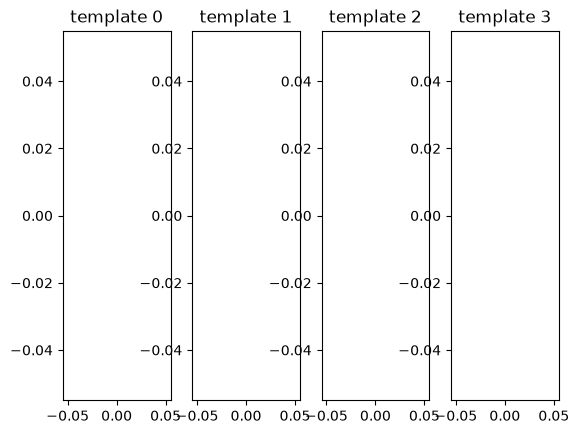

In [13]:
# mean template per unit
si.plot_unit_templates(analyzer)

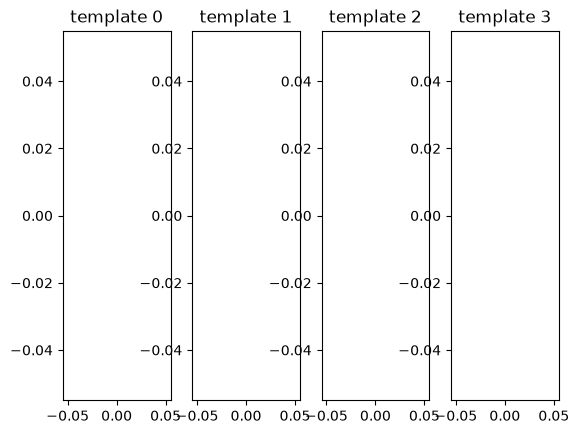

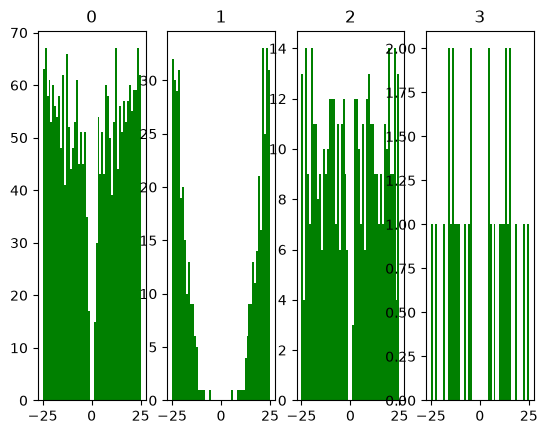

In [14]:
# individual spike waveforms + autocorrelograms per unit
si.plot_unit_waveforms(analyzer)
si.plot_autocorrelograms(analyzer)

## 7. Manual curation  ·  `css-gui`

Combinato's last step is the `css-gui` for merging/rejecting units by hand. The SpikeInterface equivalents:

- **`spikeinterface-gui`** — desktop curation app: `si.plot_sorting_summary(analyzer, backend="spikeinterface_gui")` (needs `pip install spikeinterface-gui`).
- **sortingview** — web-based, shareable: `si.plot_sorting_summary(analyzer, backend="sortingview")`.

Curation labels (merges, accept/reject) can then be applied with `si.apply_curation(...)` and the cleaned sorting exported. To save the analyzer for later:

```python
analyzer.save_as(folder="results/analyzer_CSC29", format="binary_folder")
```

In [15]:
si.export_to_phy(analyzer, output_folder="results/phy_CSC29", remove_if_exists=True)

write_binary_recording (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

/Users/alexanderflores/spikesorting/.venv/lib/python3.13/site-packages/spikeinterface/postprocessing/template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


Fitting PCA:   0%|          | 0/4 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/4 [00:00<?, ?it/s]

extract PCs (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

Run:
phy template-gui  /Users/alexanderflores/spikesorting/results/phy_CSC29/params.py


## 8. Faithful reproduction of Tutorial Part III — masked extract, both signs

Sections 1–7 use SpikeInterface's `run_sorter("combinato")`, which is convenient but (a) clusters only **one** sign per call and (b) **skips `css-mask-artifacts`** — it fuses `css-extract` + `css-simple-clustering` into a single shell script with no hook in between.

The [Combinato *Real Data* tutorial](https://github.com/jniediek/combinato/wiki/Tutorial-Real-Data) instead runs the CLI steps explicitly, **including artifact masking**, and walks through the **positive** sort (`sort_pos_simple`). To match it exactly we drive Combinato's CLI directly. A single masked `css-extract` writes both positive and negative spikes, so it feeds **both** clustering signs:

```
css-extract --h5 --files recording.h5                     # filter + detect  (pos AND neg)
css-mask-artifacts --datafile recording/data_recording.h5  # <-- the step the SI wrapper omits
css-simple-clustering        --datafile ...                # positive -> sort_pos_simple
css-simple-clustering --neg  --datafile ...                # negative -> sort_neg_simple
```

Then we load each sign with `CombinatoSortingExtractor(det_sign=...)` and compare them side by side. This is the true Tutorial-Part-III pipeline; Section 5's wrapper call is the quick-but-partial shortcut.

In [16]:
import os, sys, shutil, subprocess
import h5py
from spikeinterface.core import write_to_h5_dataset_format


def run_combinato_cli(recording, work_dir, combinato_path, verbose=True):
    """Run Combinato's CLI pipeline (extract -> mask -> cluster pos & neg) by hand.

    Reproduces Tutorial Part III, including css-mask-artifacts which the
    SpikeInterface wrapper skips. Returns the path to the `recording` result
    folder, which CombinatoSortingExtractor can load for either sign.
    """
    work_dir = Path(work_dir)
    if work_dir.exists():
        shutil.rmtree(work_dir)
    work_dir.mkdir(parents=True)

    # 1. write the recording as an h5 file css-extract can read (data in uV)
    with h5py.File(work_dir / "recording.h5", "w") as f:
        f.create_dataset("sr", data=[recording.get_sampling_frequency()], dtype="float32")
        write_to_h5_dataset_format(
            recording, dataset_path="/data", segment_index=0, file_handle=f,
            time_axis=0, single_axis=True, chunk_memory="500M", return_in_uV=True,
        )

    env = {**os.environ, "COMBINATO_PATH": str(combinato_path)}
    datafile = "recording/data_recording.h5"

    def css(script, *args, log):
        cmd = [sys.executable, f"{combinato_path}/{script}", *args]
        with open(work_dir / log, "w") as lf:
            r = subprocess.run(cmd, cwd=work_dir, env=env, stdout=lf, stderr=subprocess.STDOUT)
        if r.returncode != 0:
            raise RuntimeError(f"{script} failed (exit {r.returncode}); see {work_dir/log}")
        if verbose:
            print(f"  ✓ {script} {' '.join(args)}")

    print(f"Running Combinato CLI in {work_dir} (~2-3 min)...")
    css("css-extract", "--h5", "--files", "recording.h5", log="extract.log")   # filter + detect (pos & neg)
    css("css-mask-artifacts", "--datafile", datafile, log="mask.log")          # artifact masking
    css("css-simple-clustering", "--datafile", datafile, log="clus_pos.log")           # positive
    css("css-simple-clustering", "--neg", "--datafile", datafile, log="clus_neg.log")  # negative
    print("done.")
    return work_dir / "recording"

In [17]:
import re

# run the full masked pipeline (uses the same combinato_path resolved in Section 5)
result_folder = run_combinato_cli(raw_rec, "results/combinato_masked", combinato_path)

# how many spikes did css-mask-artifacts remove? (strip Combinato's ANSI log colors)
ansi = re.compile(r"\x1b\[[0-9;]*m")
mask_log = ansi.sub("", (result_folder.parent / "mask.log").read_text())
print("\ncss-mask-artifacts summary:")
for ln in mask_log.splitlines():
    if "masked" in ln or "Total:" in ln:
        print("  ", ln.split("mask_artifacts:", 1)[-1].strip())

Running Combinato CLI in results/combinato_masked (~2-3 min)...


  ✓ css-extract --h5 --files recording.h5


  ✓ css-mask-artifacts --datafile recording/data_recording.h5


  ✓ css-simple-clustering --datafile recording/data_recording.h5


  ✓ css-simple-clustering --neg --datafile recording/data_recording.h5
done.

css-mask-artifacts summary:
   2026-07-01 15:11:44 [DEBUG  ] combinato: Logging configured: level=DEBUG, dir=/Users/alexanderflores/spikesorting/results/combinato_masked/logs/20260701
   high_firing: detected 0 pos spikes, masked 0 in mode "first"
   Total: 0
   amplitude: detected 0 pos spikes, masked 0 in mode "first"
   Total: 0
   double: detected 145 pos spikes, masked 145 in mode "first"
   Total: 145
   high_firing: detected 0 neg spikes, masked 0 in mode "first"
   Total: 0
   amplitude: detected 0 neg spikes, masked 0 in mode "first"
   Total: 0
   double: detected 79 neg spikes, masked 79 in mode "first"
   Total: 79


In [18]:
from spikeinterface.extractors.extractor_classes import CombinatoSortingExtractor

# load each sign separately (keep_good_only drops units masking/clustering flagged as artifact)
sorting_pos = CombinatoSortingExtractor(result_folder, sampling_frequency=fs,
                                        det_sign="pos", keep_good_only=True)
sorting_neg = CombinatoSortingExtractor(result_folder, sampling_frequency=fs,
                                        det_sign="neg", keep_good_only=True)

for name, s in [("positive (sort_pos_simple)", sorting_pos),
                ("negative (sort_neg_simple)", sorting_neg)]:
    n = [len(s.get_unit_spike_train(u)) for u in s.unit_ids]
    print(f"{name:28} : {len(s.unit_ids)} units, spikes/unit = {n}")

positive (sort_pos_simple)   : 2 units, spikes/unit = [16865, 919]
negative (sort_neg_simple)   : 4 units, spikes/unit = [11451, 1252, 3277, 11877]


In [19]:
# build a SortingAnalyzer for each sign (waveforms/templates over the filtered recording)
exts = ["random_spikes", "waveforms", "templates", "noise_levels", "correlograms"]

ana_pos = si.create_sorting_analyzer(sorting_pos, rec_f)
ana_pos.compute(exts)
ana_neg = si.create_sorting_analyzer(sorting_neg, rec_f)
ana_neg.compute(exts)
print("positive:", ana_pos, "\nnegative:", ana_neg)

estimate_sparsity (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

estimate_sparsity (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/1930 [00:00<?, ?it/s]

positive: SortingAnalyzer: 1 channels - 2 units - 1 segments - memory - sparse - has recording
Loaded 5 extensions: random_spikes, waveforms, templates, noise_levels, correlograms 
negative: SortingAnalyzer: 1 channels - 4 units - 1 segments - memory - sparse - has recording
Loaded 5 extensions: random_spikes, waveforms, templates, noise_levels, correlograms


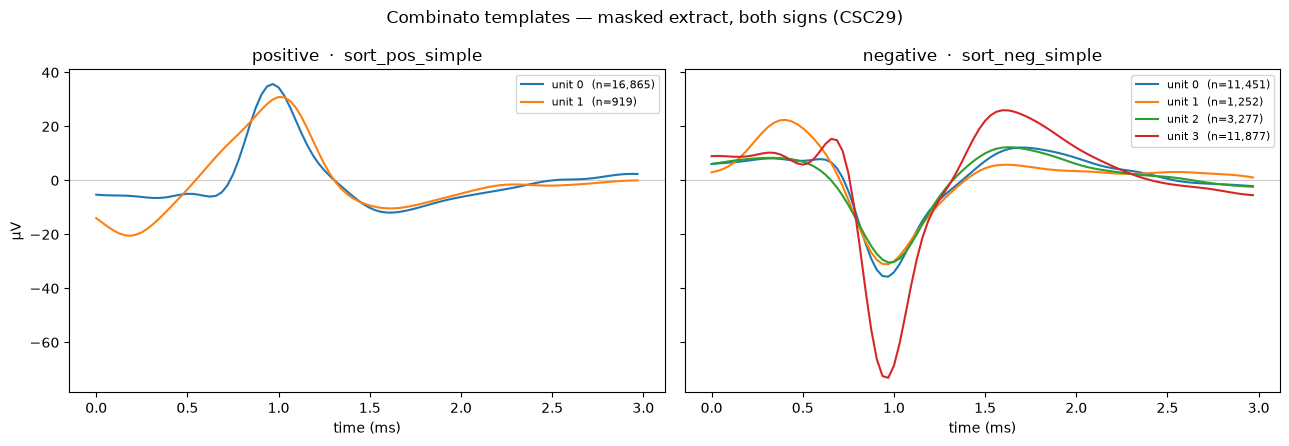

In [20]:
# side-by-side unit templates: positive vs negative sort
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, ana, title in [(axs[0], ana_pos, "positive  ·  sort_pos_simple"),
                       (axs[1], ana_neg, "negative  ·  sort_neg_simple")]:
    templates = ana.get_extension("templates").get_data()   # (units, samples, channels)
    t_ms = np.arange(templates.shape[1]) / fs * 1000
    for i, u in enumerate(ana.sorting.unit_ids):
        n = len(ana.sorting.get_unit_spike_train(u))
        ax.plot(t_ms, templates[i, :, 0], lw=1.5, label=f"unit {u}  (n={n:,})")
    ax.axhline(0, color="0.8", lw=0.8, zorder=0)
    ax.set_title(title)
    ax.set_xlabel("time (ms)")
    ax.legend(fontsize=8)

axs[0].set_ylabel("µV")
fig.suptitle("Combinato templates — masked extract, both signs (CSC29)")
fig.tight_layout()

### Notes on the two signs

- **Positive vs negative are different spikes, not the same sort with a flipped sign.** `css-extract` detects upward- and downward-going threshold crossings independently, so the two panels above are two separate populations. The tutorial walks through the **positive** sort (`sort_pos_simple`); the negative sort is what Sections 5–7 (and the phy curation) used.
- **Masking now happens.** Unlike the Section 5 wrapper, this pipeline runs `css-mask-artifacts`; the printed summary above shows how many spikes it removed (mostly "double-detection" coincidences), and `keep_good_only=True` drops any units flagged as artifacts.
- **Unit counts won't match the wrapper exactly.** Combinato's clustering is not fully deterministic, and masking shifts the input slightly, so the negative sort here differs a little from Section 5's. That's expected.

To curate either sign in phy, export it the same way as Section 7, e.g. for the positive sort:

```python
ana_pos.compute("spike_amplitudes")
si.export_to_phy(ana_pos, output_folder="results/phy_CSC29_pos", remove_if_exists=True)
```
```bash
.venv/bin/phy template-gui results/phy_CSC29_pos/params.py
```